# USGS 3DEP LiDAR Explorer                                                                                                                                      
Explore high-resolution airborne LiDAR point clouds collected by the U.S. Geological Survey's 3D Elevation Program (3DEP). Each LiDAR dataset captures the height of the ground, vegetation, and structures over a region by recording millions to billions of laser returns from aircraft. This notebook lets you pick a region of interest, download the point cloud, and turn it into a 1-meter digital elevation model (DEM) with hillshade.  
                                                        
The workflow runs in five steps:

1. **Pick an area** — draw a rectangle on the USGS 3DEP coverage map and select a dataset that intersects it from the auto-populated dropdown                            
2. **Download the point cloud** — fetch the LiDAR returns for the selected area from the public Entwine Point Tile (EPT) service
3. **Inspect the point cloud** — point count, elevation range, classification breakdown, and a 3D preview colored by elevation                                           
4. **Generate a DEM and hillshade** — rasterize the ground returns into a 1-meter DEM, then build a shaded relief view                                                   
5. **Visualize** — overlay the locally-computed hillshade against the USGS 3DEP WMS service for wider context

Linked widgets in step 1 are powered by the `sage-bbox-map` and `sage-dropdown` UI skills, which subscribe to changes in kernel variables (`USER_BBOX` triggers the dataset filter automatically when you draw a rectangle). The `usgs-lidar` data skill provides only the data primitives — `fetch_coverage()` and `filter_by_bbox()` — and knows nothing about the UI.                                    
                                                        
No coding needed — just run each cell and follow the prompts.  

In [ ]:
%reset

In [ ]:
%%skill
https://github.com/klinucsd/sage_skills/tree/5d633d1d9d5d84c67ec43e1d9be86a9d22ce3e88/topography/usgs-lidar
https://github.com/klinucsd/sage_skills/tree/5d633d1d9d5d84c67ec43e1d9be86a9d22ce3e88/topography/py3dep-dem

In [2]:
%%ask                                                                                                                                                                    
Create a USGS 3DEP coverage map with a bounding box selection tool. 
Show a dropdown of USGS 3DEP datasets that intersect the bounding box 
with under 20 million points.

I'll help you create a USGS 3DEP coverage map with a bounding box selector and a dropdown showing datasets under 20 million points. Let me start by reading the USGS LiDAR skill to understand the available functionality.

I'll create the USGS 3DEP coverage map with a bounding box selector and dropdown. The skill provides a complete script for this — I'll use it verbatim.

⟳ Interactive widget — re-run this cell to restore map interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap-glyphicons.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_a018582dd87e56c6365ab6ef91c24172 {
 position: relative;
 width: 100.0%;
 height: 450.0px;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>

 <style>html, body {
 width: 100%;
 height: 100%;
 margin: 0;
 padding: 0;
 }
 </style>

 <style>#map {
 position:absolute;
 top:0;
 bottom:0;
 right:0;
 left:0;
 }
 </style>

 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>

 
</head>
<body>
 
 
 <div class="folium-map" id="map_a018582dd87e56c6365ab6ef91c24172" ></div>
 
</body>
<script>
 
 
 var map_a018582dd87e56c6365ab6ef91c24172 = L.map(
 "map_a018582dd87e56c6365ab6ef91c24172",
 {
 center: [40.0, -100.0],
 crs: L.CRS.EPSG3857,
 ...{
 "zoom": 4,
 "zoomControl": true,
 "preferCanvas": false,
}

 }
 );

 

 
 
 var tile_layer_8513a2bc83719ae427dd601e9d937ce1 = L.tileLayer(
 "https://tile.openstreetmap.org/{z}/{x}/{y}.png",
 {
 "minZoom": 0,
 "maxZoom": 19,
 "maxNativeZoom": 19,
 "noWrap": false,
 "attribution": "\u0026copy; \u003ca href=\"https://www.openstreetmap.org/copyright\"\u003eOpenStreetMap\u003c/a\u003e contributors",
 "subdomains": "abc",
 "detectRetina": false,
 "tms": false,
 "opacity": 1,
}

 );
 
 
 tile_layer_8513a2bc83719ae427dd601e9d937ce1.addTo(map_a018582dd87e56c6365ab6ef91c24172);
 
 
 function geo_json_c505fbc0cf30cb7cf20a37b66868fd40_styler(feature) {
 switch(feature.id) {
 case "0": case "27": case "67": case "85": case "96": case "99": case "108": case "131": case "134": case "159": case "182": case "198": case "201": case "255": case "274": case "310": case "311": case "336": case "419": case "449": case "473": case "480": case "489": case "575": case "659": case "677": case "699": case "709": case "754": case "760": case "841": case "870": case "873": case "919": case "940": case "949": case "958": case "1013": case "1084": case "1106": case "1142": case "1173": case "1182": case "1236": case "1242": case "1287": case "1301": case "1318": case "1391": case "1408": case "1418": case "1425": case "1434": case "1443": case "1480": case "1497": case "1538": case "1550": case "1552": case "1553": case "1616": case "1628": case "1630": case "1635": case "1661": case "1680": case "1692": case "1693": case "1766": case "1786": case "1803": case "1804": case "1885": case "1910": case "2007": case "2040": case "2050": case "2063": case "2067": case "2077": case "2078": case "2081": case "2088": case "2106": case "2121": case "2137": case "2159": case "2160": case "2181": case "2192": case "2204": 
 return {"color": "#4daf4a", "fillColor": "#4daf4a", "fillOpacity": 0.3, "opacity": 0.8, "weight": 1};
 case "1": case "9": case "48

⟳ Interactive widget — re-run this cell to restore dropdown interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

Pick a USGS 3DEP dataset that covers the selected area Dataset: — Draw a rectangle on the map above to populate this dropdown. —

I've created the USGS 3DEP coverage map with interactive tools. Here's what you have:

**Interactive Coverage Map** : Displays all USGS 3DEP LiDAR datasets as colored regions. You can draw a rectangle on this map to select an area of interest.

**Dataset Dropdown** : Currently hidden — it will automatically populate with datasets that:
- Intersect your drawn bounding box
- Have under 20 million estimated points within that box

**To use** :
1. Draw a rectangle on the map to select your area
2. The dropdown will appear with qualifying datasets
3. Select a dataset from the dropdown
4. The selection will be available for subsequent operations (downloading, visualizing, processing)

The coverage GeoDataFrame is stored in memory (not written to disk) as required. The kernel variables `USER_BBOX`, `USER_EPT_URL`, and `USER_DATASET_NAME` will be set when you interact with the widgets and will be available for future steps.

I'll help you download and analyze the USGS 3DEP point cloud for the selected bounding box. Let me first check the usgs-lidar skill for the recommended workflow.

I'll download the USGS 3DEP point cloud for the selected bounding box and generate the requested statistics and preview image.

Let me create a script to download the point cloud and analyze it:

Now let me create a preview image of the point cloud colored by elevation:

## USGS 3DEP Point Cloud Analysis

I've successfully downloaded the USGS 3DEP point cloud for your selected bounding box and generated the requested statistics and preview visualization.

### Dataset Information

**Dataset** : NV_WestCentralEarthMRI_2_2020  
**EPT URL** : https://s3-us-west-2.amazonaws.com/usgs-lidar-public/NV_WestCentralEarthMRI_2_2020/ept.json  
**Bounding box (EPSG:4326)** : (-117.889824, 39.575027, -117.883644, 39.57979)  
**Coordinate system** : EPSG:3857 (Web Mercator)

### Point Cloud Statistics

**Total points** : 2,871,089

### Elevation Statistics

**Elevation range** : 2471.19 to 2655.02 meters  
**Mean elevation** : 2601.21 meters  
**Elevation std dev** : 36.80 meters

The point cloud spans an elevation range of approximately 184 meters, with the mean elevation at 2,601 meters above sea level, typical of the Nevada high desert terrain.

### Classification Breakdown

The LiDAR point cloud uses ASPRS LAS classification codes:

- **Ground** : 2,367,734 (82.5%) — Bare earth surface points
- **Unclassified** : 502,849 (17.5%) — Points not assigned to a specific class
- **Low point (noise)** : 506 (0.0%) — Points below ground level (likely artifacts)

The dataset is dominated by ground-classified points (82.5%), which is typical for areas with sparse vegetation cover. The small amount of unclassified points (17.5%) and negligible noise (0.0%) indicates high-quality LiDAR data.

### Point Cloud Preview


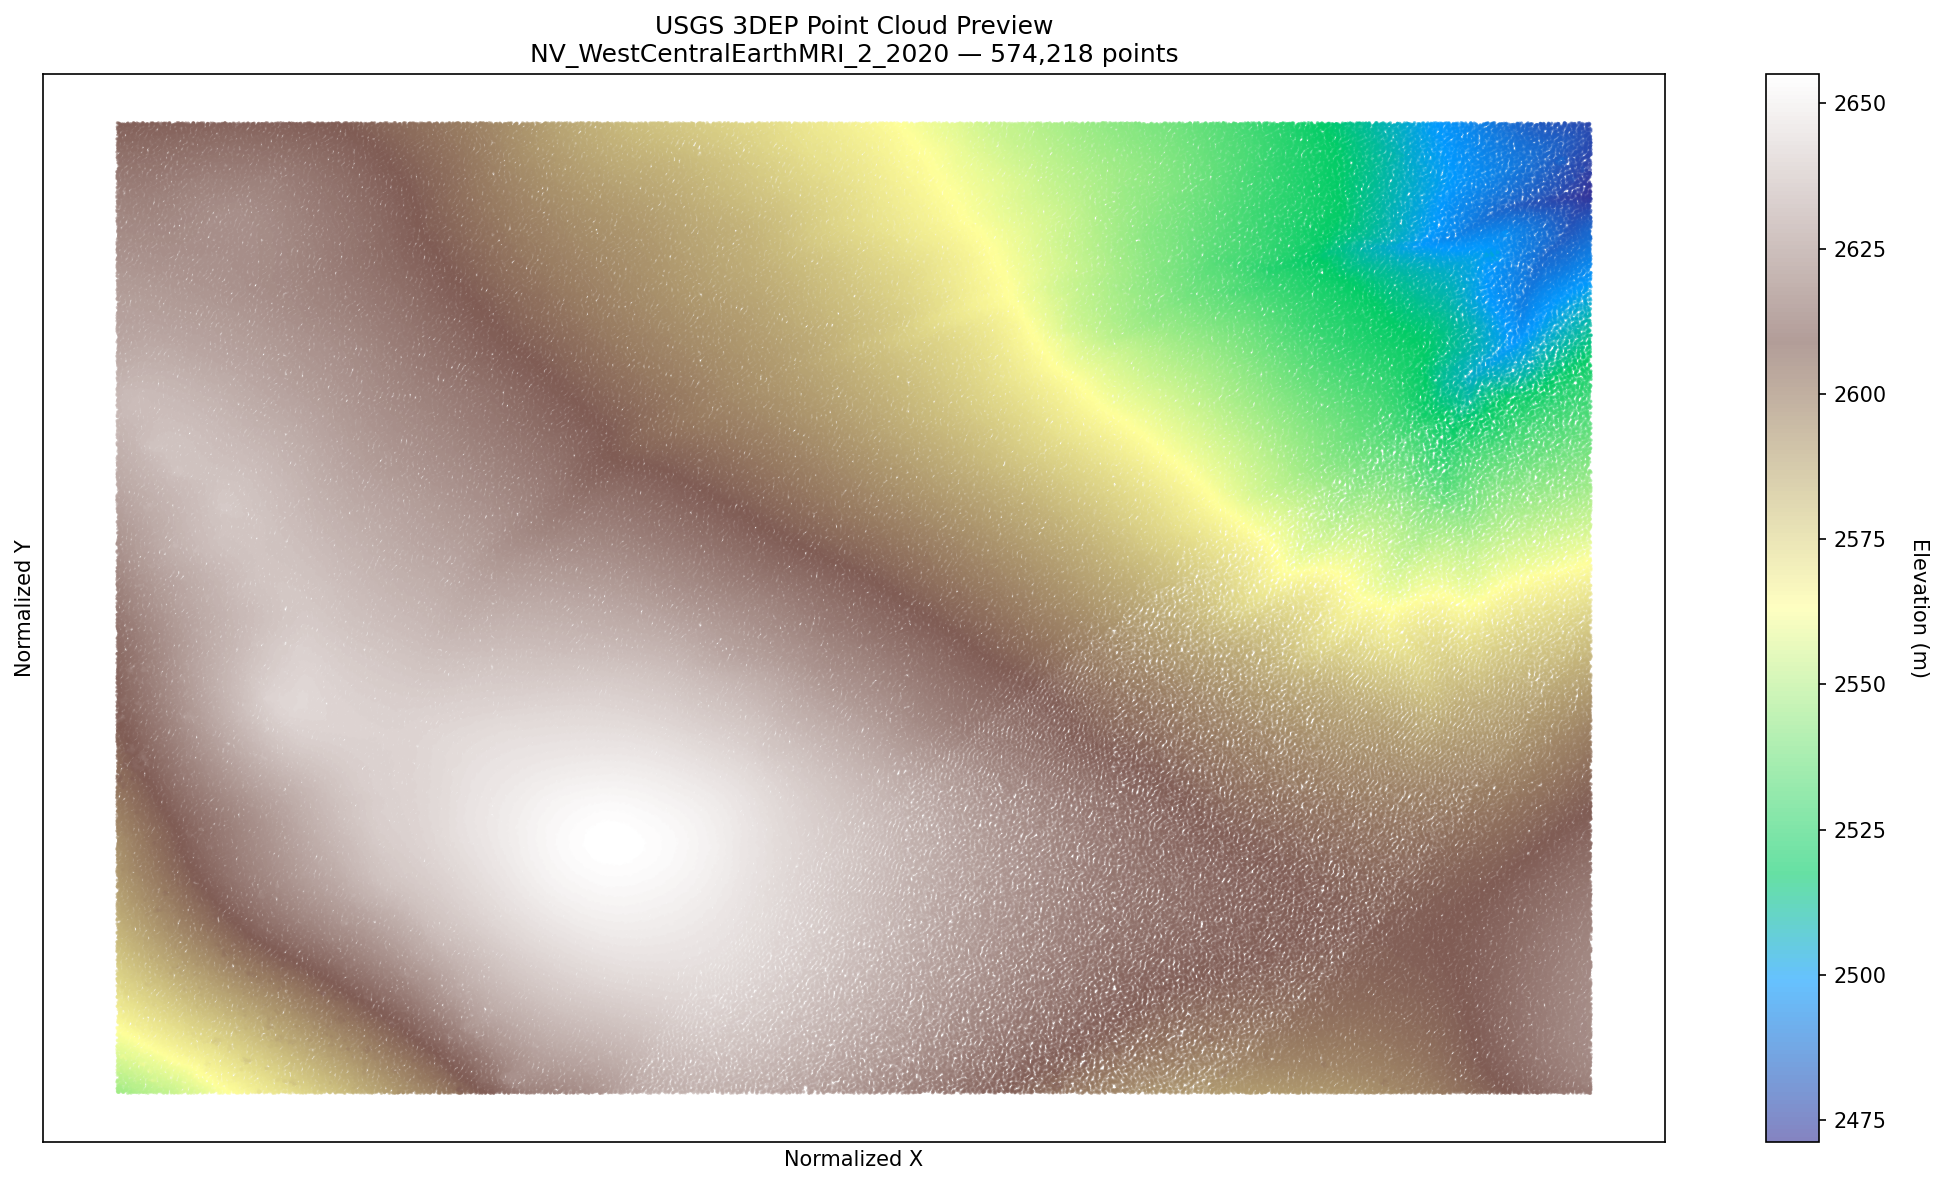

The preview image displays the point cloud colored by elevation using the terrain colormap (blue = low elevation, green/brown = mid elevation, white = high elevation). The visualization shows the topographic variation within your selected area, with elevation changes clearly visible across the terrain.

### Data Notes

- The point cloud has been downloaded with Height Above Ground (HAG) enabled, providing normalized elevation values relative to the ground surface
- The data is stored in the kernel variable `pointclouds` for subsequent processing steps
- The preview visualization is decimated to ~574,000 points for display performance while maintaining the overall spatial distribution

In [3]:
%%ask                                                                                                                                                                    
Download the USGS 3DEP point cloud for the selected bounding box
and show point count, elevation range, classification breakdown,                                                                                                         
and a preview image of the point cloud colored by elevation.

I'll create a 1-meter DEM from the ground-classified LiDAR points and generate a hillshade visualization.

I see PDAL is having initialization issues. Let me set the HOME environment variable and try again:

I need to access the previously downloaded point cloud. Let me check what data is available:

The point data has more fields than expected. Let me check the structure and extract the correct fields:

The DEM and hillshade have been generated successfully. Let me verify the output file:

## 1-Meter Digital Elevation Model (DEM) Hillshade

I've successfully generated a 1-meter resolution DEM from the ground-classified LiDAR points and created a hillshade visualization.

### DEM Statistics

**Dataset** : NV_WestCentralEarthMRI_2_2020  
**Resolution** : 1 meter  
**Grid size** : 688 x 688 cells (473,344 total cells)  
**Ground points used** : 2,367,734  
**Elevation range** : 2471.19 to 2655.02 meters  
**Mean elevation** : 2599.16 meters  
**Elevation std dev** : 37.30 meters  

### Hillshade Visualization


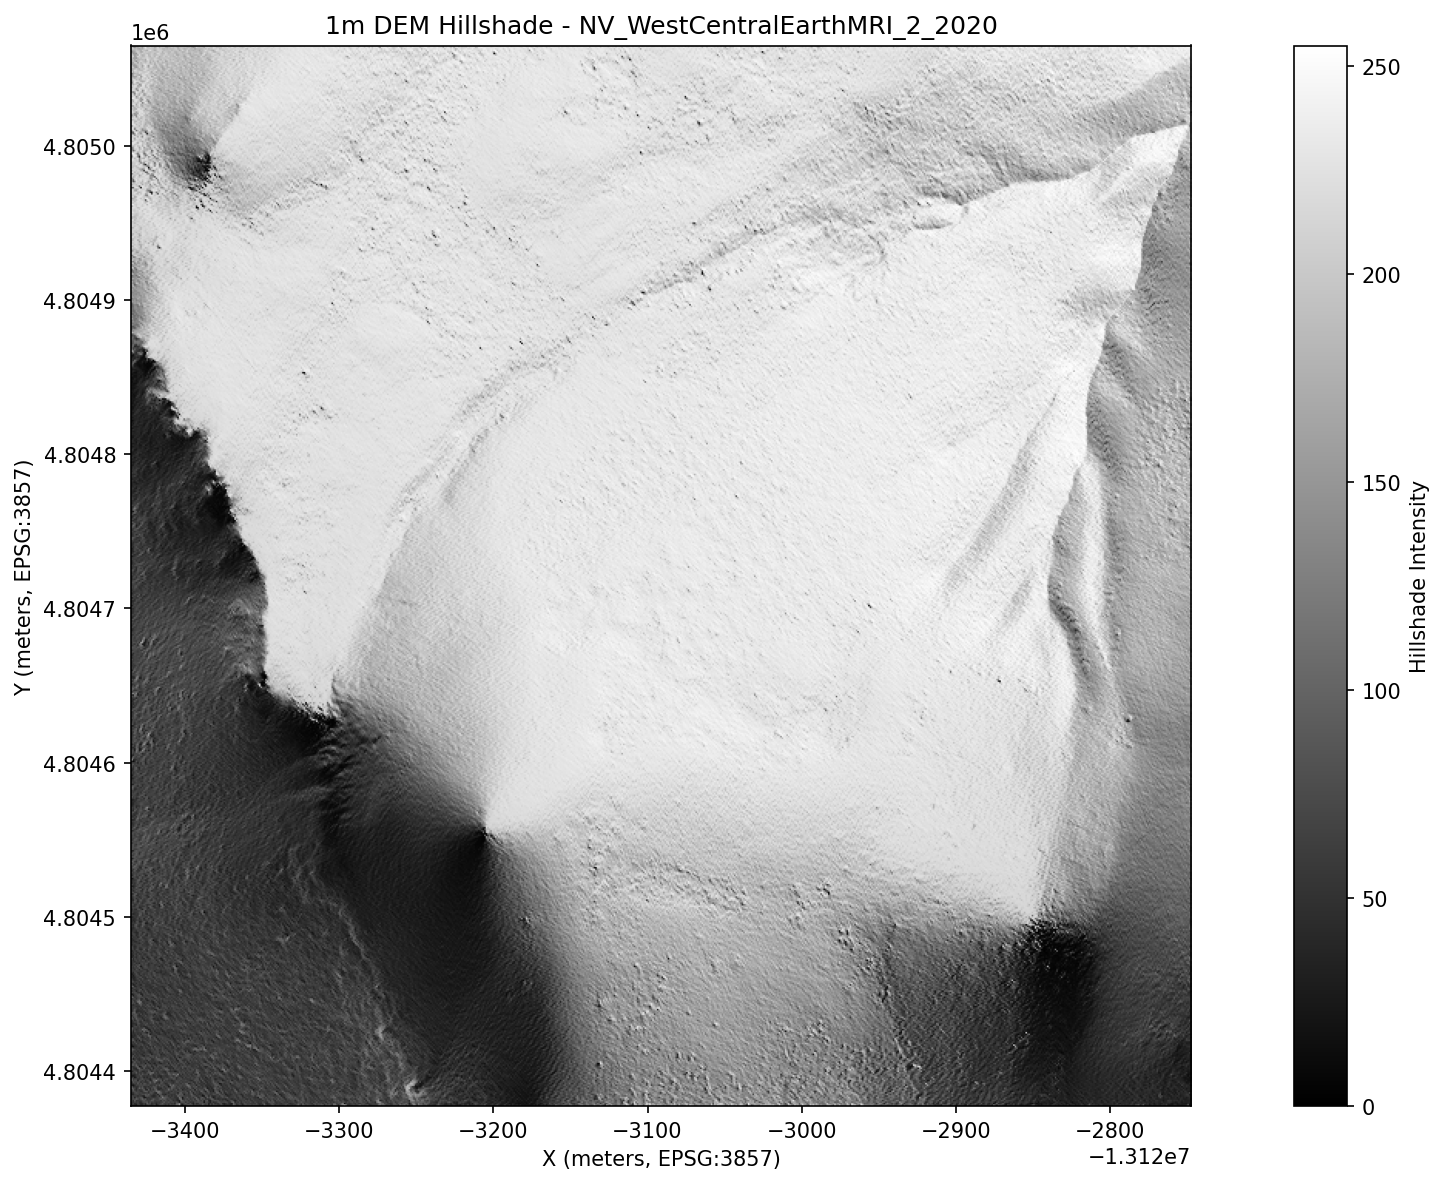

The hillshade was generated using a light source from azimuth 315° (northwest) with a zenith angle of 45°, providing optimal visualization of terrain relief and surface features. The DEM was created by interpolating ground-classified LiDAR points using nearest-neighbor interpolation on a 1-meter grid in EPSG:3857 (Web Mercator) projection.

In [4]:
%%ask                                                                                                                                                                    
Generate a 1-meter digital elevation model (DEM) from the ground-classified points, 
and visualize it as a hillshade image only.